# 03 — Binary Grade Classifier (Pipeline Validation)

Trains a binary **Low-Grade Glioma (Grade 2+3) vs High-Grade Glioma (Grade 4)** classifier.
This is a pipeline sanity check — a simpler problem before the full 3-class and 4-class tasks.

**Architecture:** MedicalNet pretrained ResNet-10 backbone + classification head  
**Training:** Two-phase — frozen backbone first, then full fine-tune  
**Primary metric:** Balanced accuracy (NOT plain accuracy — Grade 4 is 80% of data)

**Run after:** `02_eda.ipynb` (all checks passed)  
**Run before:** `04_train_grade.ipynb` — only if Cell 11 checkpoint passes

---
**Validation checkpoint (Cell 11):**
- Balanced accuracy > 0.65
- Cohen's Kappa > 0.25
- Both classes predicted (no collapse to majority)

If any of these fail, do not proceed to 04. Diagnose first.

In [1]:
# ── Cell 1: Install ────────────────────────────────────────────────────────────
!pip install torch torchvision huggingface_hub scikit-learn tqdm -q

In [2]:
# ── Cell 2: Imports, Drive mount, GPU check ────────────────────────────────────
import os, sys, json, warnings, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.metrics import (
    balanced_accuracy_score, cohen_kappa_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  ⚠️  No GPU found. Training will be very slow on CPU.')

Mounted at /content/drive
Device: cuda
  GPU : Tesla T4
  VRAM: 15.6 GB


In [ ]:
# ── Cell 3: Config ─────────────────────────────────────────────────────────────
MANIFEST_CSV = '/content/drive/MyDrive/GlioGradev2/preprocessed/manifest.csv'
MODEL_OUT    = '/content/drive/MyDrive/GlioGradev2/models'

BATCH_SIZE   = 4
EPOCHS_HEAD  = 3      # short — just warms up the head; frozen MedicalNet features
                      # are segmentation-derived and not useful for classification
EPOCHS_FULL  = 100    # was 40; model was still improving at cutoff
LR_HEAD      = 1e-3
LR_FULL      = 1e-4
FOCAL_GAMMA  = 2.0    # focal loss: down-weights easy examples, focuses on hard ones
PATIENCE     = 15     # early stopping: halt if val bal_acc doesn't improve for this many epochs
SEED         = 42
NUM_CLASSES  = 2      # binary: LGG=0, HGG=1

# Validation checkpoint thresholds (Cell 11)
MIN_BAL_ACC  = 0.65
MIN_KAPPA    = 0.25

CKPT_PATH    = Path(MODEL_OUT) / 'binary_best.pt'
HIST_PATH    = Path(MODEL_OUT) / 'binary_history.json'

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Path(MODEL_OUT).mkdir(parents=True, exist_ok=True)
print('Config ready.')
print(f'  Manifest : {MANIFEST_CSV}')
print(f'  Model out: {MODEL_OUT}')

In [4]:
# ── Cell 4: MedicalNet setup ───────────────────────────────────────────────────
# Clones the MedicalNet GitHub repo for the model definition,
# then downloads the pretrained ResNet-10 weights from HuggingFace.

!git clone https://github.com/Tencent/MedicalNet.git /content/MedicalNet --quiet 2>/dev/null || echo 'Already cloned.'
sys.path.insert(0, '/content/MedicalNet')

from huggingface_hub import hf_hub_download
weights_path = hf_hub_download(
    repo_id='TencentMedicalNet/MedicalNet-Resnet10',
    filename='resnet_10.pth'
)
print(f'\nPretrained weights: {weights_path}')

# Verify we can import the model
from models.resnet import resnet10
print('MedicalNet ResNet-10 import: ✅')

resnet_10.pth:   0%|          | 0.00/57.5M [00:00<?, ?B/s]


Pretrained weights: /root/.cache/huggingface/hub/models--TencentMedicalNet--MedicalNet-Resnet10/snapshots/deeeaa1e2a342b63e28b61e9d993b63e79c4b437/resnet_10.pth
MedicalNet ResNet-10 import: ✅


In [ ]:
# ── Cell 5: Dataset, binary labels, DataLoaders ────────────────────────────────
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from scipy.ndimage import rotate as nd_rotate


class GlioDataset(Dataset):
    """Loads preprocessed .npy volumes from the manifest. Augments training set."""

    def __init__(self, df, label_col, augment=False):
        self.df        = df.reset_index(drop=True)
        self.label_col = label_col
        self.augment   = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        vol = np.load(row['npy_path']).astype(np.float32)

        if self.augment:
            # Flip all 3 axes independently (anatomically valid for all axes)
            if random.random() > 0.5: vol = np.flip(vol, axis=0).copy()  # L-R
            if random.random() > 0.5: vol = np.flip(vol, axis=1).copy()  # A-P
            if random.random() > 0.5: vol = np.flip(vol, axis=2).copy()  # S-I
            # Random 3D rotation ±15° on a randomly chosen plane
            if random.random() > 0.5:
                angle = random.uniform(-15, 15)
                axes  = random.choice([(0, 1), (0, 2), (1, 2)])
                vol   = nd_rotate(vol, angle, axes=axes, reshape=False,
                                  order=1, mode='nearest')
            # Intensity scale + Gaussian noise
            vol = np.clip(vol * random.uniform(0.9, 1.1), 0.0, 1.0)
            vol = vol + np.random.normal(0, 0.02, vol.shape).astype(np.float32)
            vol = np.clip(vol, 0.0, 1.0)

        # (1, 96, 96, 96) — single channel
        vol   = torch.from_numpy(vol).unsqueeze(0)
        label = int(row[self.label_col])
        return vol, label


# Load manifest and create binary labels
df = pd.read_csv(MANIFEST_CSV)
df['binary_label'] = (df['grade_label'] == 4).astype(int)  # 0 = LGG, 1 = HGG

train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()

# Binary distribution
print('Binary class distribution:')
for split, sdf in [('train', train_df), ('val', val_df), ('test', test_df)]:
    lgg = (sdf['binary_label'] == 0).sum()
    hgg = (sdf['binary_label'] == 1).sum()
    print(f'  {split:<6}: LGG={lgg:>3}  HGG={hgg:>3}  total={len(sdf):>3}')

# Class weights (used in focal loss alpha)
train_labels  = train_df['binary_label'].values
raw_weights   = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_labels)
class_weights = torch.FloatTensor(raw_weights).to(device)
print(f'\nClass weights (focal loss alpha): LGG={raw_weights[0]:.3f}  HGG={raw_weights[1]:.3f}')

# Datasets
train_ds = GlioDataset(train_df, 'binary_label', augment=True)
val_ds   = GlioDataset(val_df,   'binary_label', augment=False)

# WeightedRandomSampler: ensures each training batch sees ~equal LGG / HGG.
# With batch=4 and 80% HGG, shuffle alone gives ~0.8 LGG samples per batch
# on average — many batches have zero LGG gradient. The sampler fixes this.
n_lgg = (train_df['binary_label'] == 0).sum()
n_hgg = (train_df['binary_label'] == 1).sum()
sample_weights = np.where(train_df['binary_label'].values == 0, 1.0 / n_lgg, 1.0 / n_hgg)
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)
print(f'WeightedRandomSampler: LGG weight={1/n_lgg:.4f}  HGG weight={1/n_hgg:.4f}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)}  Val batches: {len(val_loader)}')

In [8]:
# ── Cell 6: Build model ────────────────────────────────────────────────────────
# Loads MedicalNet ResNet-10 pretrained weights, replaces the segmentation
# head with a classification head, and freezes backbone for Phase 1.
#
# MedicalNet ResNet-10 may expose its output head as 'conv_seg' (segmentation
# variant) or 'fc' (classification variant). We probe the feature shape with a
# dummy forward pass so the Linear head is always sized correctly.

def build_model(num_classes, weights_path, device):
    backbone = resnet10(
        sample_input_D=96,
        sample_input_H=96,
        sample_input_W=96,
        num_seg_classes=1,
    )

    state = torch.load(weights_path, map_location='cpu')
    sd    = state.get('state_dict', state)
    sd    = {k.replace('module.', ''): v for k, v in sd.items()}
    missing, unexpected = backbone.load_state_dict(sd, strict=False)
    print(f'Pretrained weights loaded — missing: {len(missing)}  unexpected: {len(unexpected)}')
    if missing:
        print(f'  Missing keys (expected for head): {missing[:4]}')

    # Detect which attribute is the output head
    if hasattr(backbone, 'conv_seg'):
        HEAD = 'conv_seg'
    elif hasattr(backbone, 'fc'):
        HEAD = 'fc'
    else:
        raise AttributeError(
            f"Cannot find output head — children: {[n for n, _ in backbone.named_children()]}"
        )
    print(f'  Output head attribute: {HEAD!r}')

    # Temporarily replace head with Identity to probe the feature shape
    setattr(backbone, HEAD, nn.Identity())
    backbone.eval()
    with torch.no_grad():
        feat = backbone(torch.zeros(1, 1, 96, 96, 96))
    feat_shape = feat.shape
    print(f'  Feature shape before head: {feat_shape}')

    # Build classification head based on actual feature shape
    if feat.dim() == 5:
        # Spatial feature map (B, C, D, H, W) — pool then classify
        clf_head = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(feat_shape[1], 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )
    elif feat.dim() == 2:
        # Already flat (B, features)
        clf_head = nn.Sequential(
            nn.Linear(feat_shape[1], 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )
    else:
        raise ValueError(f'Unexpected feature tensor shape {feat_shape}')

    setattr(backbone, HEAD, clf_head)
    return backbone.to(device), HEAD


model, HEAD = build_model(NUM_CLASSES, weights_path, device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# Freeze backbone for Phase 1 — only the classification head trains
for name, param in model.named_parameters():
    param.requires_grad = (HEAD in name)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 trainable parameters: {trainable:,}  (head only)')

Pretrained weights loaded — missing: 12  unexpected: 0
  Missing keys (expected for head): ['conv_seg.0.weight', 'conv_seg.0.bias', 'conv_seg.1.weight', 'conv_seg.1.bias']
  Output head attribute: 'conv_seg'
  Feature shape before head: torch.Size([1, 512, 12, 12, 12])
Total parameters: 14,421,442
Phase 1 trainable parameters: 65,922  (head only)


In [ ]:
# ── Cell 7: Training & evaluation functions ────────────────────────────────────
import torch.nn.functional as F

scaler = GradScaler()   # mixed precision


class FocalLoss(nn.Module):
    """Binary/multiclass focal loss with optional per-class alpha weighting.

    gamma=2 down-weights easy (high-confidence correct) examples so the
    gradient focuses on hard examples — important for severe class imbalance.
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # per-class weight tensor (same shape as num_classes)
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce  = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt  = torch.exp(-ce)           # probability of correct class
        return (((1 - pt) ** self.gamma) * ce).mean()


criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA)
print(f'Criterion: FocalLoss(gamma={FOCAL_GAMMA}), alpha from class_weights')


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for vols, labels in loader:
        vols, labels = vols.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast():
            logits = model(vols)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * len(labels)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    bal_acc  = balanced_accuracy_score(all_labels, all_preds)
    return avg_loss, bal_acc


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for vols, labels in loader:
        vols, labels = vols.to(device), labels.to(device)
        with autocast():
            logits = model(vols)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * len(labels)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    bal_acc  = balanced_accuracy_score(all_labels, all_preds)
    return avg_loss, bal_acc, np.array(all_preds), np.array(all_labels)


def plot_history(histories, phase_boundaries=None):
    """Plot loss and balanced accuracy curves. histories is a list of dicts."""
    combined = {k: [] for k in histories[0]}
    for h in histories:
        for k, v in h.items():
            combined[k].extend(v)

    epochs = range(1, len(combined['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, combined['train_loss'], label='Train')
    ax1.plot(epochs, combined['val_loss'],   label='Val')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(epochs, combined['train_bal_acc'], label='Train')
    ax2.plot(epochs, combined['val_bal_acc'],   label='Val')
    ax2.axhline(MIN_BAL_ACC, color='red', linestyle='--', alpha=0.5, label=f'Target ({MIN_BAL_ACC})')
    ax2.set_title('Balanced Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylim(0, 1)
    ax2.legend()

    if phase_boundaries:
        for ax in (ax1, ax2):
            for b in phase_boundaries:
                ax.axvline(b, color='gray', linestyle=':', alpha=0.7)
                ax.text(b + 0.3, ax.get_ylim()[1] * 0.98, 'Phase 2', fontsize=7, color='gray')

    plt.suptitle('Training history — Binary LGG vs HGG', fontweight='bold')
    plt.tight_layout()
    plt.show()


print('Loss, train/eval functions, and plot utility ready.')

In [ ]:
# ── Cell 8: Phase 1 — Warm up classification head (backbone frozen) ───────────
# Only 3 epochs. MedicalNet was pretrained for segmentation, not classification,
# so frozen backbone features have no useful binary grade signal. This phase
# just initialises the head weights before Phase 2 unfreezes everything.
# No checkpoint is saved here — Phase 2 owns the best checkpoint.

print(f'Phase 1: {EPOCHS_HEAD} epochs, LR={LR_HEAD}, backbone frozen (head warm-up only)')
print('─' * 60)

optimizer_1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4
)

history_1 = {'train_loss': [], 'val_loss': [], 'train_bal_acc': [], 'val_bal_acc': []}

for epoch in range(1, EPOCHS_HEAD + 1):
    tr_loss, tr_acc         = train_epoch(model, train_loader, criterion, optimizer_1)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion)

    history_1['train_loss'].append(tr_loss)
    history_1['val_loss'].append(val_loss)
    history_1['train_bal_acc'].append(tr_acc)
    history_1['val_bal_acc'].append(val_acc)

    print(f'Epoch {epoch:>2}/{EPOCHS_HEAD}  '
          f'loss {tr_loss:.4f}/{val_loss:.4f}  '
          f'bal_acc {tr_acc:.3f}/{val_acc:.3f}')

print('\nPhase 1 complete. Proceeding to full fine-tune.')

In [ ]:
# ── Cell 9: Phase 2 — Full fine-tune (backbone unfrozen) ──────────────────────
# Starts from the current Phase 1 weights (head already initialised).
# All parameters are unfrozen. Early stopping on val balanced accuracy.

# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2: up to {EPOCHS_FULL} epochs, LR={LR_FULL}, early stop patience={PATIENCE}')
print(f'All {trainable:,} parameters unfrozen')
print('─' * 60)

optimizer_2 = optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=1e-4)
scheduler   = optim.lr_scheduler.CosineAnnealingLR(optimizer_2, T_max=EPOCHS_FULL)

history_2         = {'train_loss': [], 'val_loss': [], 'train_bal_acc': [], 'val_bal_acc': []}
best_val_acc_2    = 0.0
early_stop_counter = 0

for epoch in range(1, EPOCHS_FULL + 1):
    tr_loss, tr_acc         = train_epoch(model, train_loader, criterion, optimizer_2)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history_2['train_loss'].append(tr_loss)
    history_2['val_loss'].append(val_loss)
    history_2['train_bal_acc'].append(tr_acc)
    history_2['val_bal_acc'].append(val_acc)

    saved = ''
    if val_acc > best_val_acc_2:
        best_val_acc_2 = val_acc
        torch.save(model.state_dict(), str(CKPT_PATH))
        early_stop_counter = 0
        saved = ' 💾'
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.')
            break

    if epoch % 5 == 0 or epoch == 1:
        lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch:>3}/{EPOCHS_FULL}  '
              f'loss {tr_loss:.4f}/{val_loss:.4f}  '
              f'bal_acc {tr_acc:.3f}/{val_acc:.3f}  '
              f'lr {lr:.2e}{saved}')
    elif saved:
        lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch:>3}/{EPOCHS_FULL}  '
              f'loss {tr_loss:.4f}/{val_loss:.4f}  '
              f'bal_acc {tr_acc:.3f}/{val_acc:.3f}  '
              f'lr {lr:.2e}{saved}')

# Save full training history
all_history = {
    'phase1': history_1,
    'phase2': history_2,
    'best_val_bal_acc': best_val_acc_2,
}
with open(str(HIST_PATH), 'w') as f:
    json.dump(all_history, f, indent=2)

print(f'\nPhase 2 best val balanced accuracy: {best_val_acc_2:.4f}')
print(f'Checkpoint: {CKPT_PATH}')

# Plot combined training curves
plot_history([history_1, history_2], phase_boundaries=[EPOCHS_HEAD])

══════════════════════════════════════════════════
  VALIDATION RESULTS — Binary LGG vs HGG
══════════════════════════════════════════════════
  Balanced accuracy : 0.5938
  Cohen's Kappa     : 0.1215
  Macro F1          : 0.5116
  Plain accuracy    : 0.5405  (do not rely on this)

  Per-class report:
                 precision    recall  f1-score   support

LGG (Grade 2+3)      0.275     0.688     0.393        16
  HGG (Grade 4)      0.853     0.500     0.630        58

       accuracy                          0.541        74
      macro avg      0.564     0.594     0.512        74
   weighted avg      0.728     0.541     0.579        74



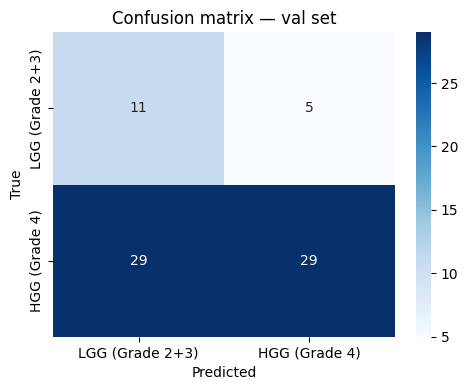

  Unique classes predicted: {0, 1}  (need both {0, 1} to pass checkpoint)


In [12]:
# ── Cell 10: Evaluate best checkpoint on validation set ────────────────────────

model.load_state_dict(torch.load(str(CKPT_PATH), map_location=device))
_, _, val_preds, val_labels = eval_epoch(model, val_loader, criterion)

CLASS_NAMES = ['LGG (Grade 2+3)', 'HGG (Grade 4)']

bal_acc = balanced_accuracy_score(val_labels, val_preds)
kappa   = cohen_kappa_score(val_labels, val_preds)
macro_f1 = f1_score(val_labels, val_preds, average='macro')
cm      = confusion_matrix(val_labels, val_preds)

print('═' * 50)
print('  VALIDATION RESULTS — Binary LGG vs HGG')
print('═' * 50)
print(f'  Balanced accuracy : {bal_acc:.4f}')
print(f'  Cohen\'s Kappa     : {kappa:.4f}')
print(f'  Macro F1          : {macro_f1:.4f}')
print(f'  Plain accuracy    : {(val_preds == val_labels).mean():.4f}  (do not rely on this)')
print()
print('  Per-class report:')
print(classification_report(val_labels, val_preds, target_names=CLASS_NAMES, digits=3))

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix — val set')
plt.tight_layout()
plt.show()

# Unique predicted classes
unique_preds = set(val_preds.tolist())
print(f'  Unique classes predicted: {unique_preds}  (need both {{0, 1}} to pass checkpoint)')

In [13]:
# ── Cell 11: Validation checkpoint — go / no-go for 04_train_grade ────────────

SEP = '═' * 58
checks = []

def chk(label, condition, detail=''):
    icon = '✅' if condition else '❌'
    suffix = f'  (got {detail})' if detail else ''
    print(f'  {icon}  {label}{suffix}')
    checks.append(condition)

print(SEP)
print('  PIPELINE VALIDATION CHECKPOINT')
print(SEP)

chk(f'Balanced accuracy > {MIN_BAL_ACC}',
    bal_acc > MIN_BAL_ACC,
    f'{bal_acc:.4f}')

chk(f'Cohen\'s Kappa > {MIN_KAPPA}',
    kappa > MIN_KAPPA,
    f'{kappa:.4f}')

chk('Both classes predicted (no majority collapse)',
    unique_preds == {0, 1},
    str(unique_preds))

chk('Checkpoint file saved to Drive',
    CKPT_PATH.exists())

print()
print(SEP)
if all(checks):
    print('  ✅  ALL CHECKS PASSED')
    print('  Proceed to 04_train_grade.ipynb')
else:
    n_fail = sum(1 for c in checks if not c)
    print(f'  ❌  {n_fail} CHECK(S) FAILED — do not proceed to 04')
    print()
    print('  Diagnostic hints:')
    if bal_acc <= MIN_BAL_ACC:
        print('  • Low balanced accuracy: check class weights are applied correctly.')
        print('    Print class_weights and verify LGG weight > HGG weight.')
        print('    Try increasing EPOCHS_FULL or lowering LR_FULL.')
    if kappa <= MIN_KAPPA:
        print('  • Low Kappa: model may be predicting near-random or majority-only.')
        print('    Inspect the confusion matrix — if one row is all zeros, the model')
        print('    collapsed to predicting one class. Class weighting is not working.')
    if unique_preds != {0, 1}:
        print('  • Only one class predicted: severe collapse. Class weights likely')
        print('    not reaching the loss function. Verify criterion = CrossEntropyLoss(weight=class_weights)')
        print('    and class_weights is on the correct device.')
print(SEP)

══════════════════════════════════════════════════════════
  PIPELINE VALIDATION CHECKPOINT
══════════════════════════════════════════════════════════
  ❌  Balanced accuracy > 0.65  (got 0.5938)
  ❌  Cohen's Kappa > 0.25  (got 0.1215)
  ✅  Both classes predicted (no majority collapse)  (got {0, 1})
  ✅  Checkpoint file saved to Drive

══════════════════════════════════════════════════════════
  ❌  2 CHECK(S) FAILED — do not proceed to 04

  Diagnostic hints:
  • Low balanced accuracy: check class weights are applied correctly.
    Print class_weights and verify LGG weight > HGG weight.
    Try increasing EPOCHS_FULL or lowering LR_FULL.
  • Low Kappa: model may be predicting near-random or majority-only.
    Inspect the confusion matrix — if one row is all zeros, the model
    collapsed to predicting one class. Class weighting is not working.
══════════════════════════════════════════════════════════
